In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow.keras import datasets, layers, models

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [ ]:
(x_train,y_train ), (x_test, y_test) =datasets.mnist.load_data()

In [ ]:
print(x_train.shape)
print(x_test.shape)


(60000, 28, 28)
(10000, 28, 28)


Text(0.5, 1.0, 'label :5')

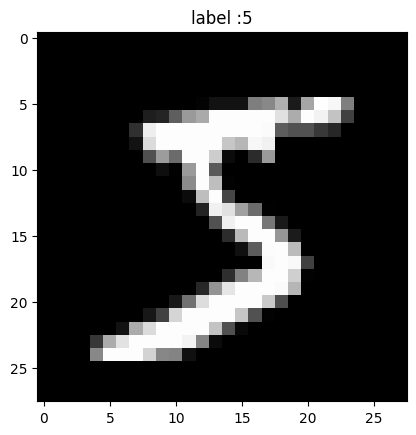

In [ ]:
plt.imshow(x_train[0],cmap='gray')
plt.title(f"label :{y_train[0]}")

In [ ]:
x_train=x_train/255
x_test=x_test/255

In [ ]:
x_train.reshape(60000,28,28,1)
x_test.reshape(10000,28,28,1)

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [ ]:
model= models.Sequential()

In [ ]:
model.add(layers.Conv2D(
    32,
     (3,3),
    activation='relu',
    input_shape=(28,28,1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(layers.MaxPooling2D((2,2)))

In [ ]:
model.add(layers.Conv2D(
    64,  #inc filters so that we can thoroughly recognise
     (3,3),
    activation='relu'))

In [ ]:
model.add(layers.MaxPooling2D((2,2)))

In [ ]:
model.add(layers.Flatten())

In [ ]:
model.add(layers.Dense(
    64,
    activation='relu'))

In [ ]:
model.add(layers.Dense(
    10,
    activation='softmax'
    ))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    x_train,
    y_train,
    epochs=8,
    validation_data=(x_test,y_test)
    )

Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 25ms/step - accuracy: 0.9529 - loss: 0.1557 - val_accuracy: 0.9821 - val_loss: 0.0515
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9842 - loss: 0.0526 - val_accuracy: 0.9853 - val_loss: 0.0429
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9881 - loss: 0.0389 - val_accuracy: 0.9863 - val_loss: 0.0452
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9904 - loss: 0.0305 - val_accuracy: 0.9899 - val_loss: 0.0331
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.9925 - loss: 0.0234 - val_accuracy: 0.9909 - val_loss: 0.0331
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9935 - loss: 0.0198 - val_accuracy: 0.9890 - val_loss: 0.0371
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9944 - loss: 0.0161 - val_accuracy: 0.9894 - val_loss: 0.0313
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.9958 - loss: 0

In [ ]:
test_loss,test_accuracy=model.evaluate(
    x_test,
    y_test
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9900 - loss: 0.0371


In [ ]:
prediction=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [ ]:
np.argmax(prediction[0])

np.int64(7)

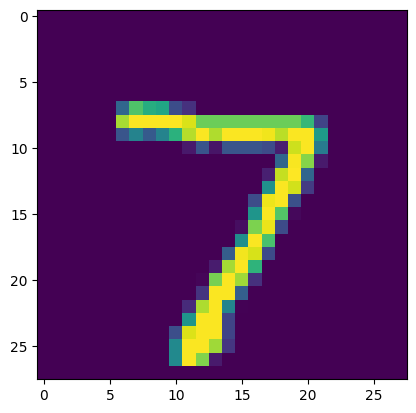

In [ ]:
plt.imshow(x_test[0].reshape(28,28))

In [ ]:
model.save("digit_recognition_project.h5")